# Extreme Price Filter — Optimal Bounds

When bid <= X or ask >= (100-X), the market is effectively decided. Quoting there risks getting picked off with no offsetting flow. Find the optimal X.

In [1]:
import io, sys
from dataclasses import dataclass
from datetime import date, timedelta

import boto3
import pandas as pd
import matplotlib.pyplot as plt
import requests

sys.path.insert(0, '../..')
from app.events import Event, OrderBookUpdate, TradeEvent, BookInvalidated
from app.strategy.mm import maker_fee_cents, OrderSideState

s3 = boto3.client('s3')
BUCKET = 'prediction-markets-data'
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load data + settlements

In [2]:
def load_silver(event_type, dates):
    frames = []
    for d in dates:
        prefix = f'silver/kalshi_ws/{event_type}/date={d}/'
        pages = s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix)
        keys = [o['Key'] for page in pages for o in page.get('Contents', [])]
        for k in keys:
            raw = s3.get_object(Bucket=BUCKET, Key=k)['Body'].read()
            frames.append(pd.read_parquet(io.BytesIO(raw)))
        if keys:
            print(f'  {event_type} {d}: {len(keys)} files')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

today = date(2026, 4, 25)
dates = [today - timedelta(days=i) for i in range(7)]

print('Loading...')
book_df = load_silver('OrderBookUpdate', dates)
trade_df = load_silver('TradeEvent', dates)
book_df = book_df[book_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()
trade_df = trade_df[trade_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()

events: list[Event] = []
for _, r in book_df.iterrows():
    events.append(OrderBookUpdate(t_receipt=r['t_receipt'], market_ticker=r['market_ticker'],
        bid_yes=int(r['bid_yes']), ask_yes=int(r['ask_yes']),
        bid_size=int(r.get('bid_size', 10000)), ask_size=int(r.get('ask_size', 10000))))
for _, r in trade_df.iterrows():
    events.append(TradeEvent(t_receipt=r['t_receipt'], market_ticker=r['market_ticker'],
        side=r['side'], price=int(r['price']), size=int(r['size'])))
events.sort(key=lambda e: e.t_receipt)
print(f'{len(events):,} events ({book_df["market_ticker"].nunique()} tickers)')

all_tickers = sorted(trade_df['market_ticker'].unique())
print(f'Looking up settlements for {len(all_tickers)} tickers...')
settlements = {}
for i, t in enumerate(all_tickers, 1):
    if i % 50 == 0 or i == len(all_tickers): print(f'  {i}/{len(all_tickers)}', end='\r')
    try:
        resp = requests.get(f'https://api.elections.kalshi.com/trade-api/v2/markets/{t}', timeout=10)
        resp.raise_for_status()
        result = resp.json().get('market', {}).get('result')
        settlements[t] = result if result in ('yes', 'no') else None
    except: settlements[t] = None
n_yes = sum(1 for v in settlements.values() if v == 'yes')
n_no = sum(1 for v in settlements.values() if v == 'no')
n_unk = sum(1 for v in settlements.values() if v is None)
print(f'\nSettlements: {n_yes} YES, {n_no} NO, {n_unk} unsettled')

Loading...
  OrderBookUpdate 2026-04-25: 1255 files
  TradeEvent 2026-04-25: 1244 files
1,664,353 events (349 tickers)
Looking up settlements for 253 tickers...
  253/253
Settlements: 65 YES, 114 NO, 74 unsettled


## 2. Strategy with configurable extreme price filter

In [3]:
@dataclass
class EPConfig:
    """Config with extreme price filter bound."""
    min_spread_cents: int = 3
    min_edge_cents: int = 1
    max_position: int = 10
    max_aggregate_position: int = 200
    order_size: int = 1
    series_filter: str = 'KXNBAPTS-'
    skew_threshold: int = 3
    agg_skew_threshold: int = 5
    agg_skew_max: int = 15
    agg_skew_step_size: int = 5
    agg_skew_step_cents: int = 1
    skew_cents_per_contract: int = 1
    age_skew_interval_s: float = 1800.0
    age_skew_step_cents: int = 1
    max_age_skew_cents: int = 10
    abs_exposure_soft_limit: int = 150
    use_player_skew: bool = True
    player_skew_cents_per_contract: int = 2
    min_trades_to_quote: int = 20
    allow_offsetting_on_tight_spread: bool = True
    use_queue_model: bool = True
    queue_ahead_cap: int = 2
    # Extreme price filter: skip when bid <= X or ask >= (100-X)
    extreme_bound: int = 0  # 0 = disabled


class EPClient:
    def __init__(self, strategy):
        self._s = strategy
        self._resting = {}
        self._next_id = 0

    def place_limit(self, ticker, side, price, size, t, queue_ahead=0):
        oid = f'bt-{self._next_id}'; self._next_id += 1
        self._resting[oid] = {'ticker': ticker, 'side': side, 'price': price,
                              'remaining': size, 'queue_ahead': queue_ahead}
        self._s.on_order_ack(ticker, side, oid)

    def cancel(self, ticker, side, order_id, t):
        self._resting.pop(order_id, None)
        self._s.on_cancel_ack(ticker, side)

    def check_fill(self, trade):
        for oid in list(self._resting):
            info = self._resting.get(oid)
            if info is None or info['ticker'] != trade.market_ticker: continue
            matched = ((info['side'] == 'bid' and trade.side == 'no' and trade.price == info['price'])
                       or (info['side'] == 'ask' and trade.side == 'yes' and trade.price == info['price']))
            if not matched: continue
            queue = info.get('queue_ahead', 0) if self._s._config.use_queue_model else 0
            available = trade.size - queue
            if available <= 0: continue
            fs = min(info['remaining'], available)
            info['remaining'] -= fs
            if info['remaining'] <= 0: del self._resting[oid]
            self._s.on_fill(info['ticker'], info['side'], fs,
                           info['remaining'] if oid in self._resting else 0,
                           info['price'], oid, trade.t_receipt)
            return


class EPStrategy:
    def __init__(self, config):
        self._config = config
        self._client = None
        self._positions = {}
        self._aggregate_abs_position = 0
        self._agg_net_position = 0
        self._order_state = {}
        self._last_quote = {}
        self.fills = []
        self._position_opened_at = {}
        self._player_positions = {}
        self._trade_counts = {}
        self._current_update = None

    def set_client(self, c): self._client = c

    @staticmethod
    def _player_key(t):
        parts = t.split('-')
        return parts[2] if len(parts) >= 4 else None

    def _get_side(self, t, s):
        if t not in self._order_state:
            self._order_state[t] = {'bid': OrderSideState(), 'ask': OrderSideState()}
        return self._order_state[t][s]

    def on_event(self, event):
        if isinstance(event, OrderBookUpdate): self._on_book_update(event)
        elif isinstance(event, TradeEvent): self._on_trade(event)

    def on_order_ack(self, t, s, oid):
        st = self._get_side(t, s)
        if st.state == 'pending': st.state = 'resting'; st.order_id = oid

    def on_cancel_ack(self, t, s):
        st = self._get_side(t, s)
        st.state = 'idle'; st.order_id = None; st.price = None

    def on_fill(self, ticker, side, fill_size, remaining, price, oid, t):
        pb = self._positions.get(ticker, 0)
        delta = fill_size if side == 'bid' else -fill_size
        pa = pb + delta
        self._positions[ticker] = pa
        self._aggregate_abs_position = sum(abs(v) for v in self._positions.values())
        self._agg_net_position = sum(self._positions.values())
        if pb == 0 and pa != 0: self._position_opened_at[ticker] = t
        elif pa == 0: self._position_opened_at.pop(ticker, None)
        pk = self._player_key(ticker)
        if pk: self._player_positions[pk] = self._player_positions.get(pk, 0) + delta
        st = self._get_side(ticker, side)
        st.remaining_size = remaining
        if remaining == 0: st.state = 'idle'; st.order_id = None; st.price = None
        self.fills.append({'t_receipt': t, 'market_ticker': ticker,
            'side': 'buy' if side == 'bid' else 'sell', 'price': price,
            'fill_size': fill_size, 'position_before': pb, 'position_after': pa,
            'maker_fee': maker_fee_cents(price)})

    def _agg_skew_adjustment(self):
        net = self._agg_net_position; cfg = self._config
        ba, aa, sb, sa = 0, 0, False, False
        if net <= -cfg.agg_skew_max: sa = True
        elif net <= -cfg.agg_skew_threshold:
            aa = ((-net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1) * cfg.agg_skew_step_cents
        if net >= cfg.agg_skew_max: sb = True
        elif net >= cfg.agg_skew_threshold:
            ba = ((net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1) * cfg.agg_skew_step_cents
        return ba, aa, sb, sa

    def _on_book_update(self, u):
        ticker = u.market_ticker
        if not ticker.startswith(self._config.series_filter): return
        spread = u.ask_yes - u.bid_yes
        if spread <= 0: return

        # --- Extreme price filter ---
        eb = self._config.extreme_bound
        if eb > 0 and (u.bid_yes <= eb or u.ask_yes >= (100 - eb)):
            for side in ('bid', 'ask'):
                st = self._get_side(ticker, side)
                if st.state == 'resting':
                    st.state = 'cancel_pending'
                    self._client.cancel(ticker, side, st.order_id or '', u.t_receipt)
            return

        position = self._positions.get(ticker, 0)
        mid = (u.bid_yes + u.ask_yes) // 2
        fee = maker_fee_cents(mid)
        nhs = (spread // 2) - fee
        rnb = rna = None

        if nhs < self._config.min_edge_cents:
            if self._config.allow_offsetting_on_tight_spread:
                if position >= 0: rnb = 'spread_narrow'
                if position <= 0: rna = 'spread_narrow'
            else: rnb = 'spread_narrow'; rna = 'spread_narrow'
        if position >= self._config.max_position: rnb = 'pos_limit'
        if position <= -self._config.max_position: rna = 'pos_limit'
        if self._aggregate_abs_position >= self._config.max_aggregate_position:
            if rnb is None: rnb = 'agg_limit'
            if rna is None: rna = 'agg_limit'
        if self._config.min_trades_to_quote > 0:
            if self._trade_counts.get(ticker, 0) < self._config.min_trades_to_quote:
                if rnb is None: rnb = 'low_volume'
                if rna is None: rna = 'low_volume'
        if (self._config.abs_exposure_soft_limit > 0
                and self._aggregate_abs_position >= self._config.abs_exposure_soft_limit):
            if position >= 0 and rnb is None: rnb = 'abs_soft_limit'
            if position <= 0 and rna is None: rna = 'abs_soft_limit'

        bp, ap = u.bid_yes, u.ask_yes
        if self._config.skew_cents_per_contract > 0 and abs(position) >= self._config.skew_threshold:
            skew = abs(position) * self._config.skew_cents_per_contract
            if position > 0: bp = max(1, bp - skew)
            else: ap = min(99, ap + skew)
        if self._config.age_skew_interval_s > 0 and position != 0:
            oa = self._position_opened_at.get(ticker)
            if oa is not None:
                at = int((u.t_receipt - oa) / self._config.age_skew_interval_s)
                ask = min(at * self._config.age_skew_step_cents, self._config.max_age_skew_cents)
                if ask > 0:
                    if position > 0: bp = max(1, bp - ask)
                    else: ap = min(99, ap + ask)
        if self._config.use_player_skew:
            pk = self._player_key(ticker)
            if pk:
                pp = self._player_positions.get(pk, 0)
                if pp != 0:
                    ps = abs(pp) * self._config.player_skew_cents_per_contract
                    if pp > 0: bp = max(1, bp - ps)
                    else: ap = min(99, ap + ps)

        ba, aa, sb, sa = self._agg_skew_adjustment()
        if sb: rnb = rnb or 'agg_skew'
        elif ba > 0: bp = max(1, bp - ba)
        if sa: rna = rna or 'agg_skew'
        elif aa > 0: ap = min(99, ap + aa)

        self._current_update = u
        self._maybe_update(ticker, 'bid', bp if rnb is None else None, u.t_receipt)
        self._maybe_update(ticker, 'ask', ap if rna is None else None, u.t_receipt)
        self._current_update = None

    def _on_trade(self, trade):
        if not trade.market_ticker.startswith(self._config.series_filter): return
        self._trade_counts[trade.market_ticker] = self._trade_counts.get(trade.market_ticker, 0) + 1
        self._client.check_fill(trade)

    def _maybe_update(self, ticker, side, price, t):
        st = self._get_side(ticker, side)
        if price is None:
            if st.state == 'resting':
                st.state = 'cancel_pending'
                self._client.cancel(ticker, side, st.order_id or '', t)
            return
        if st.state == 'idle':
            u = self._current_update
            qa = 0
            if u is not None and self._config.use_queue_model:
                qa = min(u.bid_size if side == 'bid' else u.ask_size, self._config.queue_ahead_cap)
            st.state = 'pending'; st.price = price; st.remaining_size = self._config.order_size
            self._client.place_limit(ticker, side, price, self._config.order_size, t, qa)
        elif st.state == 'resting' and st.price != price:
            st.state = 'cancel_pending'
            self._client.cancel(ticker, side, st.order_id or '', t)

## 3. Backtest engine + sweep

In [4]:
def run_bt(config, events, settlements):
    s = EPStrategy(config); c = EPClient(s); s.set_client(c)
    for e in events: s.on_event(e)
    if not s.fills:
        return {k: 0 for k in ['fills','round_trips','realized_pnl','win_rate',
                'settled_pnl','total_pnl','open_positions','max_abs_exposure',
                'settled_wins','settled_losses','tickers_quoted']}
    fills = pd.DataFrame(s.fills)
    realized = rt_count = rt_wins = 0
    for t, g in fills.groupby('market_ticker'):
        buys = g[g['side']=='buy'].sort_values('t_receipt')
        sells = g[g['side']=='sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        for i in range(pairs):
            b, se = buys.iloc[i], sells.iloc[i]
            pnl = se['price'] - b['price'] - b['maker_fee'] - se['maker_fee']
            realized += pnl; rt_count += 1
            if pnl > 0: rt_wins += 1
    settled_pnl = settled_wins = settled_losses = open_count = 0
    for t, g in fills.groupby('market_ticker'):
        pos = g['position_after'].iloc[-1]
        if pos == 0: continue
        buys = g[g['side']=='buy'].sort_values('t_receipt')
        sells = g[g['side']=='sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        unpaired = buys.iloc[pairs:] if pos > 0 else sells.iloc[pairs:]
        stl = settlements.get(t)
        if stl is None: open_count += abs(pos); continue
        for _, f in unpaired.iterrows():
            if pos > 0:
                p = (100 - f['price']) - f['maker_fee'] if stl == 'yes' else -(f['price'] + f['maker_fee'])
            else:
                p = f['price'] - f['maker_fee'] if stl == 'no' else -(100 - f['price'] + f['maker_fee'])
            settled_pnl += p
            if p > 0: settled_wins += 1
            else: settled_losses += 1
    positions = {}; max_abs = 0
    for _, f in fills.iterrows():
        positions[f['market_ticker']] = f['position_after']
        max_abs = max(max_abs, sum(abs(v) for v in positions.values()))
    return {
        'fills': len(fills), 'round_trips': rt_count,
        'realized_pnl': realized,
        'win_rate': rt_wins / rt_count if rt_count > 0 else 0,
        'settled_pnl': settled_pnl, 'total_pnl': realized + settled_pnl,
        'open_positions': open_count, 'max_abs_exposure': max_abs,
        'settled_wins': settled_wins, 'settled_losses': settled_losses,
        'tickers_quoted': fills['market_ticker'].nunique(),
    }

# Sweep extreme_bound from 0 (disabled) to 30
bounds = [0, 2, 5, 8, 10, 12, 15, 18, 20, 25, 30]
results = []
for b in bounds:
    cfg = EPConfig(extreme_bound=b)
    r = run_bt(cfg, events, settlements)
    r['name'] = f'bound={b}' if b > 0 else 'disabled'
    r['bound'] = b
    results.append(r)
    print(f"  bound={b:<3d}  total={r['total_pnl']:+6.0f}c  "
          f"realized={r['realized_pnl']:+6.0f}c  settled={r['settled_pnl']:+6.0f}c  "
          f"fills={r['fills']:>4}  rt={r['round_trips']:>3}  "
          f"win={r['win_rate']:.0%}  tickers={r['tickers_quoted']:>3}  "
          f"open={r['open_positions']:>3}  max_abs={r['max_abs_exposure']:>3}  "
          f"settled_W/L={r['settled_wins']}/{r['settled_losses']}")

rdf = pd.DataFrame(results)
best = rdf.loc[rdf['total_pnl'].idxmax()]
print(f"\nBest: bound={int(best['bound'])} → {best['total_pnl']:+.0f}c total P&L")

  bound=0    total= +1322c  realized= +1623c  settled=  -301c  fills= 319  rt=109  win=75%  tickers= 85  open=  0  max_abs=103  settled_W/L=18/83
  bound=2    total= +1055c  realized= +1048c  settled=    +7c  fills= 331  rt=129  win=72%  tickers= 77  open=  0  max_abs= 75  settled_W/L=35/38
  bound=5    total=  +868c  realized=  +788c  settled=   +80c  fills= 289  rt=108  win=73%  tickers= 75  open=  0  max_abs= 74  settled_W/L=36/37
  bound=8    total= +1288c  realized=  +865c  settled=  +423c  fills= 265  rt=101  win=78%  tickers= 74  open=  0  max_abs= 63  settled_W/L=34/29
  bound=10   total= +1200c  realized=  +856c  settled=  +344c  fills= 263  rt=100  win=78%  tickers= 74  open=  0  max_abs= 63  settled_W/L=33/30
  bound=12   total= +1092c  realized=  +876c  settled=  +216c  fills= 287  rt=113  win=78%  tickers= 71  open=  0  max_abs= 61  settled_W/L=30/31
  bound=15   total=  +889c  realized=  +870c  settled=   +19c  fills= 275  rt=104  win=80%  tickers= 71  open=  0  max_abs= 

## 4. Visualize

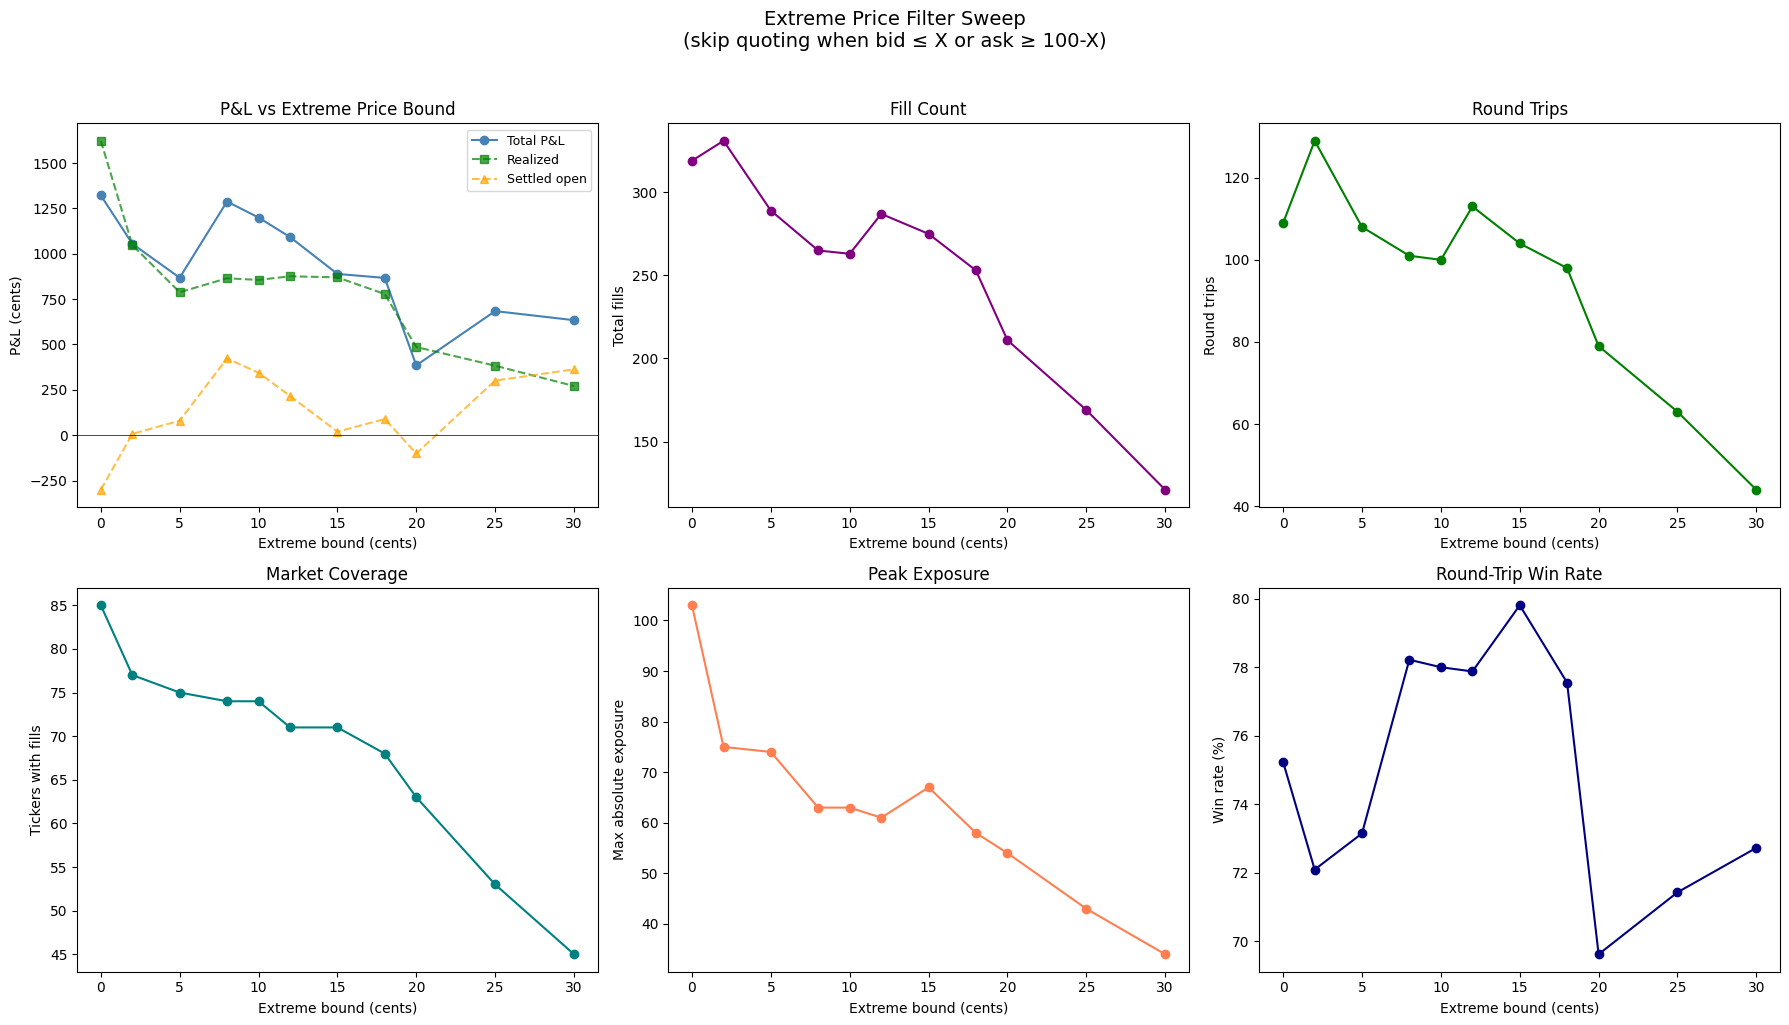

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.plot(rdf['bound'], rdf['total_pnl'], 'o-', color='steelblue', label='Total P&L')
ax.plot(rdf['bound'], rdf['realized_pnl'], 's--', color='green', alpha=0.7, label='Realized')
ax.plot(rdf['bound'], rdf['settled_pnl'], '^--', color='orange', alpha=0.7, label='Settled open')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('P&L (cents)')
ax.set_title('P&L vs Extreme Price Bound')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.plot(rdf['bound'], rdf['fills'], 'o-', color='purple')
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('Total fills')
ax.set_title('Fill Count')

ax = axes[0, 2]
ax.plot(rdf['bound'], rdf['round_trips'], 'o-', color='green')
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('Round trips')
ax.set_title('Round Trips')

ax = axes[1, 0]
ax.plot(rdf['bound'], rdf['tickers_quoted'], 'o-', color='teal')
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('Tickers with fills')
ax.set_title('Market Coverage')

ax = axes[1, 1]
ax.plot(rdf['bound'], rdf['max_abs_exposure'], 'o-', color='coral')
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('Max absolute exposure')
ax.set_title('Peak Exposure')

ax = axes[1, 2]
ax.plot(rdf['bound'], rdf['win_rate'] * 100, 'o-', color='navy')
ax.set_xlabel('Extreme bound (cents)')
ax.set_ylabel('Win rate (%)')
ax.set_title('Round-Trip Win Rate')

plt.suptitle('Extreme Price Filter Sweep\n(skip quoting when bid ≤ X or ask ≥ 100-X)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Asymmetric bounds

The filter might work better asymmetric — different thresholds for low bid vs high ask, since short YES positions (high ask) have different risk profiles than long YES positions (low bid).

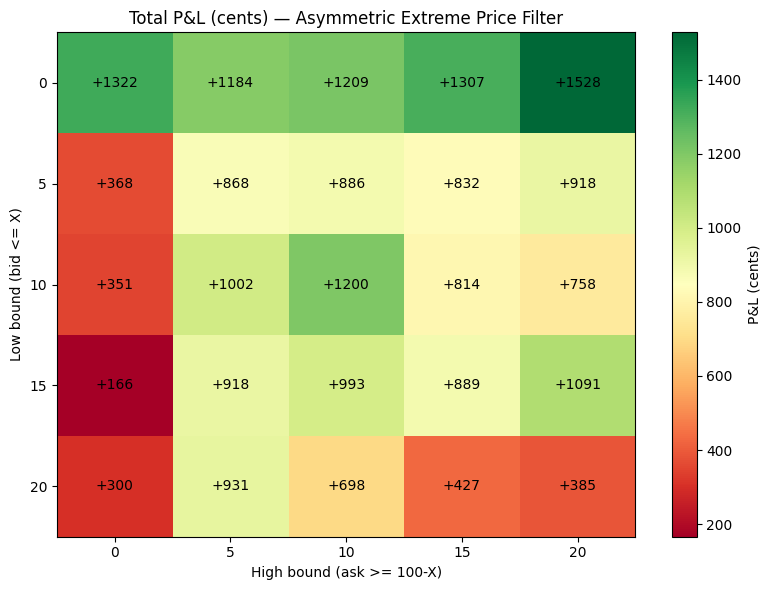

Best asymmetric: low=0, high=20 -> +1528c
  fills=397  rt=160  win=78%  tickers=78


In [6]:
def _compute_pnl(s, settlements):
    if not s.fills:
        return {k: 0 for k in ['fills','round_trips','realized_pnl','win_rate',
                'settled_pnl','total_pnl','open_positions','max_abs_exposure',
                'tickers_quoted']}
    fills = pd.DataFrame(s.fills)
    realized = rt_count = rt_wins = 0
    for t, g in fills.groupby('market_ticker'):
        buys = g[g['side']=='buy'].sort_values('t_receipt')
        sells = g[g['side']=='sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        for i in range(pairs):
            b, se = buys.iloc[i], sells.iloc[i]
            pnl = se['price'] - b['price'] - b['maker_fee'] - se['maker_fee']
            realized += pnl; rt_count += 1
            if pnl > 0: rt_wins += 1
    settled_pnl = open_count = 0
    for t, g in fills.groupby('market_ticker'):
        pos = g['position_after'].iloc[-1]
        if pos == 0: continue
        buys = g[g['side']=='buy'].sort_values('t_receipt')
        sells = g[g['side']=='sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        unpaired = buys.iloc[pairs:] if pos > 0 else sells.iloc[pairs:]
        stl = settlements.get(t)
        if stl is None: open_count += abs(pos); continue
        for _, f in unpaired.iterrows():
            if pos > 0:
                p = (100 - f['price']) - f['maker_fee'] if stl == 'yes' else -(f['price'] + f['maker_fee'])
            else:
                p = f['price'] - f['maker_fee'] if stl == 'no' else -(100 - f['price'] + f['maker_fee'])
            settled_pnl += p
    positions = {}; max_abs = 0
    for _, f in fills.iterrows():
        positions[f['market_ticker']] = f['position_after']
        max_abs = max(max_abs, sum(abs(v) for v in positions.values()))
    return {
        'fills': len(fills), 'round_trips': rt_count,
        'realized_pnl': realized,
        'win_rate': rt_wins / rt_count if rt_count > 0 else 0,
        'settled_pnl': settled_pnl, 'total_pnl': realized + settled_pnl,
        'open_positions': open_count, 'max_abs_exposure': max_abs,
        'tickers_quoted': fills['market_ticker'].nunique(),
    }

# Test asymmetric: vary low_bound (bid <= X) and high_bound (ask >= 100-X) independently
asym_results = []
for low in [0, 5, 10, 15, 20]:
    for high in [0, 5, 10, 15, 20]:
        if low == 0 and high == 0:
            label = 'disabled'
        else:
            label = f'lo={low}_hi={high}'

        cfg = EPConfig(extreme_bound=0)
        s = EPStrategy(cfg); c = EPClient(s); s.set_client(c)

        orig = s._on_book_update
        def make_filtered(lo, hi, orig_fn):
            def filtered(u):
                if lo > 0 and u.bid_yes <= lo:
                    for side in ('bid', 'ask'):
                        st = s._get_side(u.market_ticker, side)
                        if st.state == 'resting':
                            st.state = 'cancel_pending'
                            c.cancel(u.market_ticker, side, st.order_id or '', u.t_receipt)
                    return
                if hi > 0 and u.ask_yes >= (100 - hi):
                    for side in ('bid', 'ask'):
                        st = s._get_side(u.market_ticker, side)
                        if st.state == 'resting':
                            st.state = 'cancel_pending'
                            c.cancel(u.market_ticker, side, st.order_id or '', u.t_receipt)
                    return
                orig_fn(u)
            return filtered
        s._on_book_update = make_filtered(low, high, orig)

        for e in events: s.on_event(e)
        r = _compute_pnl(s, settlements)
        r['name'] = label
        r['low_bound'] = low
        r['high_bound'] = high
        asym_results.append(r)

adf = pd.DataFrame(asym_results)
pivot = adf.pivot(index='low_bound', columns='high_bound', values='total_pnl')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('High bound (ask >= 100-X)')
ax.set_ylabel('Low bound (bid <= X)')
ax.set_title('Total P&L (cents) — Asymmetric Extreme Price Filter')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:+.0f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='P&L (cents)')
plt.tight_layout()
plt.show()

best_asym = adf.loc[adf['total_pnl'].idxmax()]
print(f"Best asymmetric: low={int(best_asym['low_bound'])}, high={int(best_asym['high_bound'])} -> {best_asym['total_pnl']:+.0f}c")
print(f"  fills={int(best_asym['fills'])}  rt={int(best_asym['round_trips'])}  "
      f"win={best_asym['win_rate']:.0%}  tickers={int(best_asym['tickers_quoted'])}")

## 6. Summary

In [7]:
print('=' * 70)
print('RECOMMENDATION')
print('=' * 70)

# Compare symmetric best vs asymmetric best vs disabled
disabled = rdf[rdf['bound'] == 0].iloc[0]
sym_best = rdf.loc[rdf['total_pnl'].idxmax()]
asym_best = adf.loc[adf['total_pnl'].idxmax()]

print(f'\n{"":30s} {"Disabled":>10s}  {"Sym best":>10s}  {"Asym best":>10s}')
print(f'{"Config":30s} {"bound=0":>10s}  {"bound="+str(int(sym_best["bound"])):>10s}  '
      f'{"lo="+str(int(asym_best["low_bound"]))+"/hi="+str(int(asym_best["high_bound"])):>10s}')
print(f'{"Total P&L":30s} {disabled["total_pnl"]:+10.0f}c {sym_best["total_pnl"]:+10.0f}c {asym_best["total_pnl"]:+10.0f}c')
print(f'{"Realized P&L":30s} {disabled["realized_pnl"]:+10.0f}c {sym_best["realized_pnl"]:+10.0f}c {asym_best["realized_pnl"]:+10.0f}c')
print(f'{"Settled open P&L":30s} {disabled["settled_pnl"]:+10.0f}c {sym_best["settled_pnl"]:+10.0f}c {asym_best["settled_pnl"]:+10.0f}c')
print(f'{"Fills":30s} {disabled["fills"]:10.0f}  {sym_best["fills"]:10.0f}  {asym_best["fills"]:10.0f}')
print(f'{"Round-trips":30s} {disabled["round_trips"]:10.0f}  {sym_best["round_trips"]:10.0f}  {asym_best["round_trips"]:10.0f}')
print(f'{"Win rate":30s} {disabled["win_rate"]:10.0%}  {sym_best["win_rate"]:10.0%}  {asym_best["win_rate"]:10.0%}')
print(f'{"Tickers quoted":30s} {disabled["tickers_quoted"]:10.0f}  {sym_best["tickers_quoted"]:10.0f}  {asym_best["tickers_quoted"]:10.0f}')
print(f'{"Max abs exposure":30s} {disabled["max_abs_exposure"]:10.0f}  {sym_best["max_abs_exposure"]:10.0f}  {asym_best["max_abs_exposure"]:10.0f}')

RECOMMENDATION

                                 Disabled    Sym best   Asym best
Config                            bound=0     bound=0  lo=0/hi=20
Total P&L                           +1322c      +1322c      +1528c
Realized P&L                        +1623c      +1623c      +1575c
Settled open P&L                     -301c       -301c        -47c
Fills                                 319         319         397
Round-trips                           109         109         160
Win rate                              75%         75%         78%
Tickers quoted                         85          85          78
Max abs exposure                      103         103          78
